# INTD 555 Project 1: Regression Analysis


# Proposal
This project uses the Marketing Outcome Prediction option, which involves predicting sales based on advertising expenditures across TV, Radio, and Social Media, and analyzing which marketing channels have the greatest impact (University of Alberta, 2026).

The purpose of this project is to analyze the relationship between marketing expenditures and sales using the provided advertising dataset. The dataset contains numerical variables representing promotion budgets for TV, Radio, and Social Media, as well as a categorical variable for the type of Social Media influencer. These variables will be used to predict Sales.

The initial step will involve data inspection, including checking data types, identifying missing values, and understanding the distribution of variables. Data cleaning will include removing rows with missing values and standardizing categorical variables where necessary.

To explore relationships between variables, scatter plots will be used to visualize the association between each promotion type and sales. Social Media data may also be further divided by influencer type to assess whether specific categories exhibit stronger relationships. These visualizations will guide the selection of an appropriate modelling approach.

Given the primarily two-dimensional relationships in the dataset, a simple linear regression model will likely be the most appropriate approach applied to each promotion type to quantify the relationship between marketing expenditure and sales. This choice is appropriate given the expectation of linear relationships between promotion budgets and sales, which will be assessed through scatter plot visualizations.


##  Dataset Description
The dataset, Dummy Data HSS.csv, was downloaded from "Dummy Marketing and Sales Data
Data of TV, Influencer, Radio, and Social Media Ads budget to predict Sales" (Saragih, n.d.) on https://www.kaggle.com/.

The dataset was created for use in courses such as Data-Driven Marketing and Data Science for Business and includes the following variables:
>*   TV promotion budget (in million)
>*   Social Media promotion budget (in million)
>*   Radio promotion budget (in million)
>*   Influencer: Whether the promotion collaborate with Mega, Macro, Nano, Micro influencer
>*   Sales (in million)
>
>This data can be used for simple tasks:
>*   Data preprocessing
>*   Exploratory Data Analysis
>*   Visualization
>*   Prediction using Linear Regression and Model Evaluation
>
> (Saragih, n.d.)

In [1]:
'''
Upload the file Dummy Data HSS.csv
Import pandas, mathpltlib.pyplot, and numpy
'''
# Uncomment line below to remove existing cloned repository to allow clean rerun of the project
# !rm -rf INTD555

# Clone repository to import data file
!git clone https://github.com/emathes2/INTD555.git

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import statsmodels.api as sm

Cloning into 'INTD555'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 27 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 578.18 KiB | 6.88 MiB/s, done.


# Data Preparation
In preparation to analyze the data a number of steps were performed.

Step 1: Verify that the dataset is successfully imported and examine the structure and data types of each variable.

In [2]:
m_o_p = pd.read_csv('INTD555/Project1/Dummy Data HSS.csv')
m_o_p.head(10)

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


In [3]:
print(m_o_p.shape)

(4572, 5)


In [4]:
# Check the shape of the data file
print('Shape of dataset: ')
print(m_o_p.shape)
print()

# Check data type in each column
print('Column data types: ')
print(m_o_p.dtypes)
print()

# Quantifying missing data in each column
print('Missing values distribution: ')
print(m_o_p.isnull().mean())
print()

# Determining the different types of Influencers
print('Influencer types: ')
print(m_o_p['Influencer'].unique())

Shape of dataset: 
(4572, 5)

Column data types: 
TV              float64
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object

Missing values distribution: 
TV              0.002187
Radio           0.000875
Social Media    0.001312
Influencer      0.000000
Sales           0.001312
dtype: float64

Influencer types: 
['Mega' 'Micro' 'Nano' 'Macro']


Step 2: Clean the data. The dataset contains multiple promotion methods, so separating it into subsets allows each promotion variable to be analyzed separately, particularly for regression modeling. This approach also preserves valid observations in other variables when removing rows with missing values.

In [5]:
'''
Separate the data into subsets so each variable can be cleaned and
analyzed independently, preserving valid observations in other columns
when removing rows with missing values. Since the proportion of missing
data is very low (maximum of 0.2% in the TV data), removing these rows
is unlikely to significantly impact the overall dataset.
'''
# TV vs Sales data
tv_sales = m_o_p[['TV','Sales']].copy()

# Radio vs Sales data
radio_sales = m_o_p[['Radio','Sales']].copy()

# Social Media & influencer vs sales
s_m_sales = m_o_p[['Social Media','Influencer','Sales']].copy()

In [6]:
# Removing leading and trailing characters/white spaces from
# Influencer (str type) column
s_m_sales['Influencer'] = s_m_sales['Influencer'].str.strip()

# Clearing out the null data for each new dataset
tv_sales = tv_sales.dropna()
radio_sales = radio_sales.dropna()
s_m_sales = s_m_sales.dropna()

# Printing the statistics to verify
print('Missing values distribution:')
print('\nTV vs Sales')
print(tv_sales.isnull().mean())
print('\nRadio vs Sales:')
print(radio_sales.isnull().mean())
print('\nSocial Media vs Sales:')
print(s_m_sales.isnull().mean())

Missing values distribution:

TV vs Sales
TV       0.0
Sales    0.0
dtype: float64

Radio vs Sales:
Radio    0.0
Sales    0.0
dtype: float64

Social Media vs Sales:
Social Media    0.0
Influencer      0.0
Sales           0.0
dtype: float64


Step 3: Create preliminary visualizations using scatter plots to examine the relationship between promotion budgets and sales, and to identify potential correlations.

Text(0, 0.5, 'Sales (in millions)')

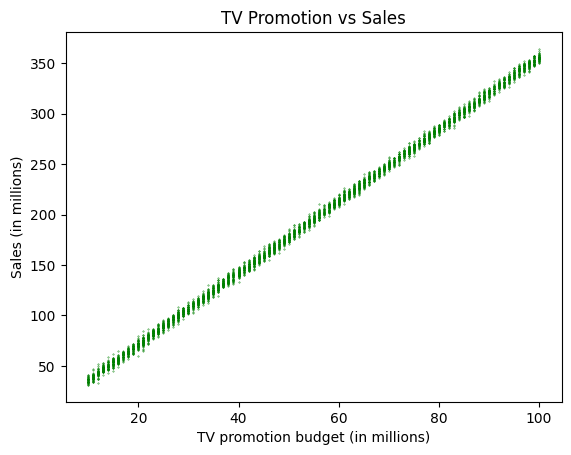

In [7]:
# Scatter plot of TV vs Sales
plt.scatter(x=tv_sales['TV'],y=tv_sales['Sales'], color='green', s=0.1)

# Adding title and labels to x-axis and y-axis
plt.title("TV Promotion vs Sales")
plt.xlabel("TV promotion budget (in millions)")
plt.ylabel("Sales (in millions)")

Text(0, 0.5, 'Sales (in millions)')

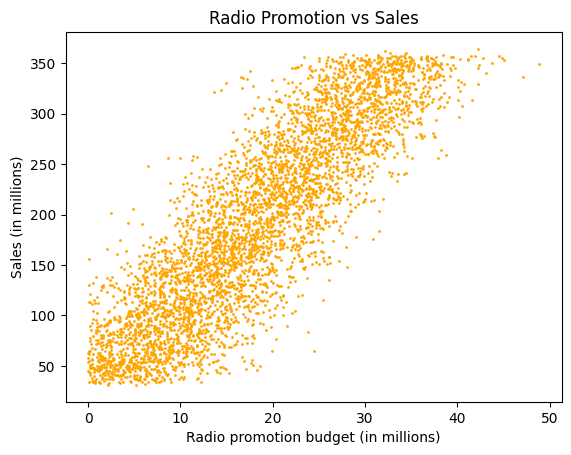

In [8]:
# Scatter plot of Radio vs Sales
plt.scatter(x=radio_sales['Radio'],y=radio_sales['Sales'], color='orange', s=1)

# Adding title and labels to x-axis and y-axis
plt.title("Radio Promotion vs Sales")
plt.xlabel("Radio promotion budget (in millions)")
plt.ylabel("Sales (in millions)")

Text(0, 0.5, 'Sales (in millions)')

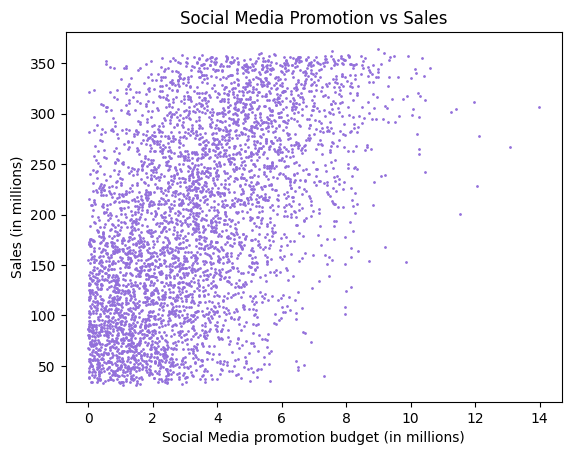

In [9]:
# Scatter plot of Social Media vs Sales
plt.scatter(x=s_m_sales['Social Media'],y=s_m_sales['Sales'], color='mediumpurple', s=1)

# Adding title and labels to x-axis and y-axis
plt.title("Social Media Promotion vs Sales")
plt.xlabel("Social Media promotion budget (in millions)")
plt.ylabel("Sales (in millions)")

# Interpretation of Plots

### 1) TV Promotion vs Sales Plot
The scatter plot of TV promotion budget versus sales shows a strong positive linear relationship. The data points are tightly clustered along a straight line, indicating minimal variability at each budget level. This suggests that TV advertising is a strong predictor of sales, and a simple linear regression model is highly appropriate for this relationship.

### 2) Radio Promotion vs Sales Plot
The Radio promotion plot shows a positive relationship between budget and sales; however, the data points exhibit greater variability compared to the TV plot. While a linear trend is still evident, the increased spread suggests that predictions may be less precise. A linear regression model remains appropriate, though it is expected to produce lower performance metrics compared to the TV model.

### 3) Social Media Promotion vs Sales Plot
The Social Media plot displays significant variability and a less clearly defined linear relationship. While there is a general upward trend, the wide spread of data points suggests that additional factors may influence sales. To better understand this relationship, the data is further divided by influencer type to examine whether specific influencer categories exhibit stronger correlations with sales.

In [10]:
# Splitting the Social Media dataset into subsets based on Influencer
s_m_mega = s_m_sales[s_m_sales['Influencer'] == 'Mega'].copy()
s_m_macro = s_m_sales[s_m_sales['Influencer'] == 'Macro'].copy()
s_m_micro = s_m_sales[s_m_sales['Influencer'] == 'Micro'].copy()
s_m_nano = s_m_sales[s_m_sales['Influencer'] == 'Nano'].copy()

Text(0, 0.5, 'Sales (in millions)')

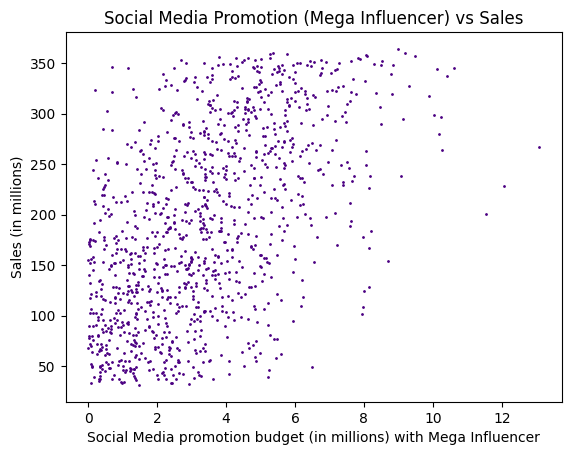

In [11]:
# Scatter plot of Mega Social Media Influencer vs Sales
plt.scatter(x=s_m_mega['Social Media'],y=s_m_mega['Sales'], color='indigo', s=1)

# Adding title and labels to x-axis and y-axis
plt.title("Social Media Promotion (Mega Influencer) vs Sales")
plt.xlabel("Social Media promotion budget (in millions) with Mega Influencer")
plt.ylabel("Sales (in millions)")

Text(0, 0.5, 'Sales (in millions)')

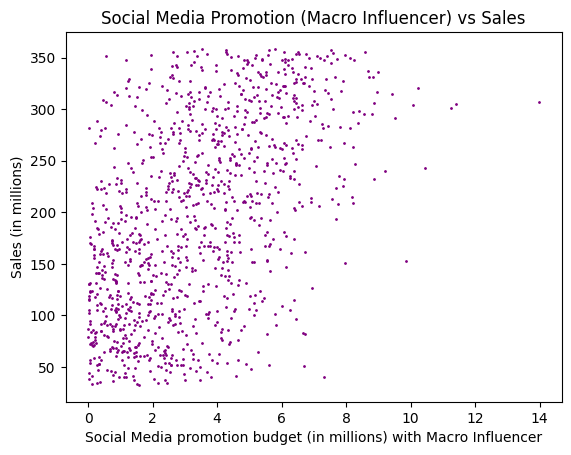

In [12]:
# Scatter plot of Macro Social Media Influencer vs Sales
plt.scatter(x=s_m_macro['Social Media'],y=s_m_macro['Sales'], color='purple', s=1)

# Adding title and labels to x-axis and y-axis
plt.title("Social Media Promotion (Macro Influencer) vs Sales")
plt.xlabel("Social Media promotion budget (in millions) with Macro Influencer")
plt.ylabel("Sales (in millions)")

Text(0, 0.5, 'Sales (in millions)')

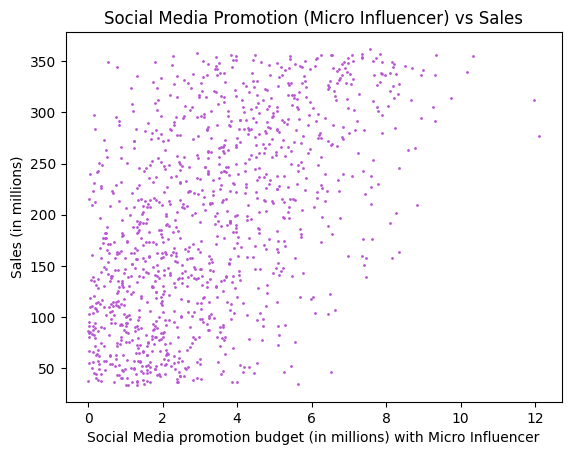

In [13]:
# Scatter plot of Micro Social Media Influencer vs Sales
plt.scatter(x=s_m_micro['Social Media'],y=s_m_micro['Sales'], color='mediumorchid', s=1)

# Adding title and labels to x-axis and y-axis
plt.title("Social Media Promotion (Micro Influencer) vs Sales")
plt.xlabel("Social Media promotion budget (in millions) with Micro Influencer")
plt.ylabel("Sales (in millions)")

Text(0, 0.5, 'Sales (in millions)')

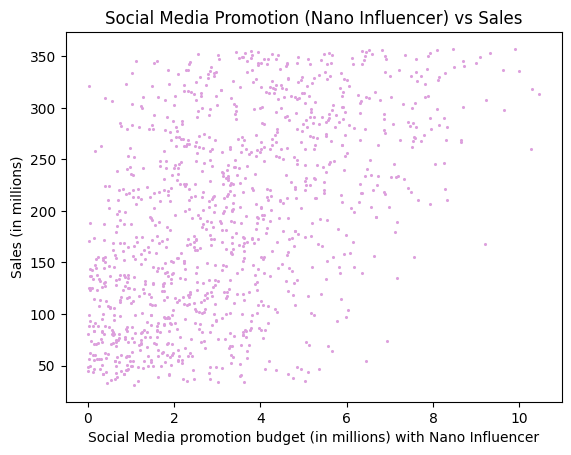

In [14]:
# Scatter plot of Nano Social Media Influencer vs Sales
plt.scatter(x=s_m_nano['Social Media'],y=s_m_nano['Sales'], color='plum', s=1.5)

# Adding title and labels to x-axis and y-axis
plt.title("Social Media Promotion (Nano Influencer) vs Sales")
plt.xlabel("Social Media promotion budget (in millions) with Nano Influencer")
plt.ylabel("Sales (in millions)")

# Interpretation of Plots (continued)

### 3a) Social Media vs Sales (by Influencer)

The Social Media data was divided by influencer type (Mega, Macro, Micro, and Nano) to examine if specific categories exhibited stronger relationships with sales. Across all influencer types, a general upward trend between promotion budget and sales is observed; however, each plot continues to show substantial variability, with data points widely dispersed.

While some categories show slightly stronger clustering at higher budget levels, no group demonstrates a clearly strong linear relationship comparable to that observed in TV promotions or even Radio promotions. Overall, separating the data by influencer type does not significantly reduce variability, indicating that influencer category alone is not a strong predictor of sales.

As a result, regression analysis will be conducted on the Social Media data as a whole.

# Regression Analysis
Correlation coefficients are calculated to quantify the strength of the relationships observed in the plots.

In [15]:
# Calculate the correlation coefficients
print('Correlation Coefficients for TV Promotion')
Pearsons_r_tv=scipy.stats.pearsonr(tv_sales['TV'], tv_sales['Sales']).correlation
print(f"Pearson's r={Pearsons_r_tv}")

Spearman_r_tv=scipy.stats.spearmanr(tv_sales['TV'], tv_sales['Sales']).correlation
print(f"Spearman's rho={Spearman_r_tv}")

Kendalls_tau_tv=scipy.stats.kendalltau(tv_sales['TV'], tv_sales['Sales']).correlation
print(f"Kendall's tau={Kendalls_tau_tv}")
print()

print('Correlation Coefficients for Radio Promotion')
Pearsons_r_radio=scipy.stats.pearsonr(radio_sales['Radio'], radio_sales['Sales']).correlation
print(f"Pearson's r={Pearsons_r_radio}")

Spearman_r_radio=scipy.stats.spearmanr(radio_sales['Radio'], radio_sales['Sales']).correlation
print(f"Spearman's rho={Spearman_r_radio}")

Kendalls_tau_radio=scipy.stats.kendalltau(radio_sales['Radio'], radio_sales['Sales']).correlation
print(f"Kendall's tau={Kendalls_tau_radio}")
print()

print('Correlation Coefficients for Social Media Promotion')
Pearsons_r_s_m=scipy.stats.pearsonr(s_m_sales['Social Media'], s_m_sales['Sales']).correlation
print(f"Pearson's r={Pearsons_r_s_m}")

Spearman_r_s_m=scipy.stats.spearmanr(s_m_sales['Social Media'], s_m_sales['Sales']).correlation
print(f"Spearman's rho={Spearman_r_s_m}")

Kendalls_tau_s_m=scipy.stats.kendalltau(s_m_sales['Social Media'], s_m_sales['Sales']).correlation
print(f"Kendall's tau={Kendalls_tau_s_m}")

Correlation Coefficients for TV Promotion
Pearson's r=0.9994974449413364
Spearman's rho=0.9994954380100358
Kendall's tau=0.983696202650733

Correlation Coefficients for Radio Promotion
Pearson's r=0.8691047673423389
Spearman's rho=0.8738587627858814
Kendall's tau=0.6781878575010424

Correlation Coefficients for Social Media Promotion
Pearson's r=0.528906002644342
Spearman's rho=0.5295757565129843
Kendall's tau=0.3633453011779284


These correlation results support the observed relationships, confirming a strong linear association for TV, a moderate-to-strong association for Radio, and a weaker association for Social Media.

### Regression analysis for the TV Promotion vs Sales data.

In [16]:
# defining the variables
x_tv = tv_sales['TV'].tolist()
y_tv = tv_sales['Sales'].tolist()

# adding the constant term
x_c_tv = sm.add_constant(x_tv)

# performing the regression
# and fitting the model
result_tv = sm.OLS(y_tv, x_c_tv).fit()

# printing the summary table along with slope and intercept
print(result_tv.summary())
print()
tv_slope = result_tv.params[1]
tv_intercept = result_tv.params[0]
print('Slope:', tv_slope)
print('Intercept:', tv_intercept)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:07:17   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1263      0.101     -1.257      0.2

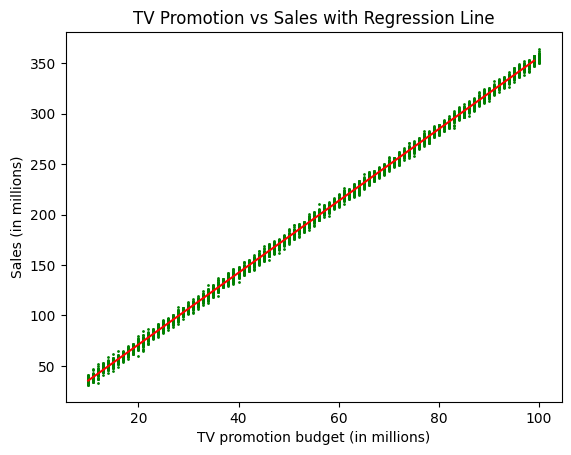

In [17]:
# finding the maximum and minimum
# values of x, to get the
# range of data
max_x_tv = tv_sales['TV'].max()
min_x_tv = tv_sales['TV'].min()

# range of values for plotting
# the regression line
x_range_tv = np.arange(min_x_tv, max_x_tv, 1)

# the substituted equation for regression line
# y_predicted = slope of the regression line X x + y intercept
y_predicted_tv = tv_slope * x_range_tv + tv_intercept

# plotting the data and the regression line
plt.scatter(x_tv, y_tv, color='green', s=1)
plt.plot(x_range_tv, y_predicted_tv, 'r')
plt.title('TV Promotion vs Sales with Regression Line')
plt.xlabel('TV promotion budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()

The regression results confirm an extremely strong linear relationship (R² ≈ 0.999), indicating that TV promotion budget is a highly reliable predictor of sales. The slope of approximately 3.56 suggests that for every additional million spent on TV promotion, sales increase by about 3.56 million. The close fit of the regression line to the data indicates minimal variability and high predictive accuracy.

### Regression analysis for the Radio Promotion vs Sales data.

In [18]:
# defining the variables
x_radio = radio_sales['Radio'].tolist()
y_radio = radio_sales['Sales'].tolist()

# adding the constant term
x_c_radio = sm.add_constant(x_radio)

# performing the regression
# and fitting the model
result_radio = sm.OLS(y_radio, x_c_radio).fit()

# printing the summary table along with slope and intercept
print(result_radio.summary())
print()
radio_slope = result_radio.params[1]
radio_intercept = result_radio.params[0]
print('Slope:', radio_slope)
print('Intercept:', radio_intercept)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                 1.408e+04
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:07:17   Log-Likelihood:                -23943.
No. Observations:                4562   AIC:                         4.789e+04
Df Residuals:                    4560   BIC:                         4.790e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         40.5577      1.450     27.962      0.0

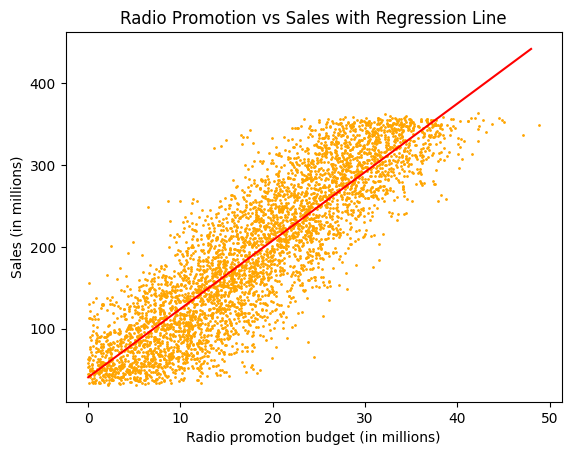

In [19]:
# finding the maximum and minimum
# values of x, to get the
# range of data
max_x_radio = radio_sales['Radio'].max()
min_x_radio = radio_sales['Radio'].min()

# range of values for plotting
# the regression line
x_range_radio = np.arange(min_x_radio, max_x_radio, 1)

# the substituted equation for regression line
# y_predicted = slope of the regression line X x + y intercept
y_predicted_radio = radio_slope * x_range_radio + radio_intercept

# plotting the data and the regression line
plt.scatter(x_radio, y_radio, color='orange', s=1)
plt.plot(x_range_radio, y_predicted_radio, 'r')
plt.title('Radio Promotion vs Sales with Regression Line')
plt.xlabel('Radio promotion budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()

The regression results show a strong positive relationship between Radio promotion and sales (R² ≈ 0.755), indicating good predictive capability. The slope of approximately 8.36 suggests that each additional million spent on Radio promotion is associated with an increase of about 8.36 million in sales. However, the greater spread of data points compared to TV indicates higher variability and slightly reduced predictive reliability.

### Regression analysis for the Social Media vs Sales data.

In [20]:
# defining the variables
x_s_m = s_m_sales['Social Media'].tolist()
y_s_m = s_m_sales['Sales'].tolist()

# adding the constant term
x_c_s_m = sm.add_constant(x_s_m)

# performing the regression
# and fitting the model
result_s_m = sm.OLS(y_s_m, x_c_s_m).fit()

# printing the summary table along with slope and intercept
print(result_s_m.summary())
print()
s_m_slope = result_s_m.params[1]
s_m_intercept = result_s_m.params[0]
print('Slope:', s_m_slope)
print('Intercept:', s_m_intercept)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     1770.
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:07:18   Log-Likelihood:                -26397.
No. Observations:                4560   AIC:                         5.280e+04
Df Residuals:                    4558   BIC:                         5.281e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        118.4069      2.114     56.020      0.0

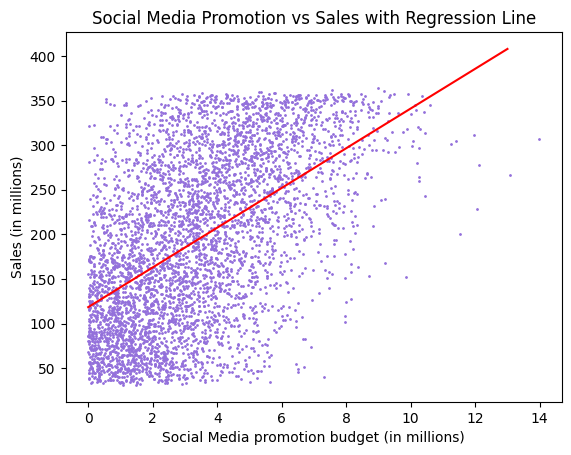

In [21]:
# finding the maximum and minimum
# values of x, to get the
# range of data
max_x_s_m = s_m_sales['Social Media'].max()
min_x_s_m = s_m_sales['Social Media'].min()

# range of values for plotting
# the regression line
x_range_s_m = np.arange(min_x_s_m, max_x_s_m, 1)

# the substituted equation for regression line
# y_predicted = slope of the regression line X x + y intercept
y_predicted_s_m = s_m_slope * x_range_s_m + s_m_intercept

# plotting the data and the regression line
plt.scatter(x_s_m, y_s_m, color='mediumpurple', s=1)
plt.plot(x_range_s_m, y_predicted_s_m, 'r')
plt.title('Social Media Promotion vs Sales with Regression Line')
plt.xlabel('Social Media promotion budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()

The regression results indicate a weaker relationship between Social Media promotion and sales (R² ≈ 0.280), showing that only a limited portion of sales variation is explained by this variable. The slope of approximately 22.27 suggests a positive association; however, the wide dispersion of data points indicates substantial variability. The regression line captures the overall upward trend but does not closely follow the main clustering of data points, as ordinary least squares regression minimizes error across all observations, including widely dispersed values, rather than only the densest cluster.

# Summative Report

This analysis predicts sales based on promotion budget across TV, Radio, and Social Media. Linear regression results show that TV promotion is the strongest predictor of sales (R² ≈ 0.999), followed by Radio (R² ≈ 0.755). Social Media demonstrates a weaker relationship (R² ≈ 0.280), indicating high variability and lower predictive reliability. Overall, TV advertising has the most significant and consistent impact on sales, while Social Media effectiveness is likely influenced by additional factors not present in the dataset. Based on these findings, businesses should prioritize investment in TV advertising for the most reliable sales impact, while using Social Media more strategically in combination with other factors.

# References

1.   Saragih, H. (n.d.). Dummy advertising and sales data. Kaggle. https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data/

2.   University of Alberta. (2026). Project 1: Project descriptions. INT D 555: Fundamentals of Data Science & AI.



